# Finetuning with PyTorch

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

In [13]:
device_str = "cpu"
if torch.cuda.is_available():
    device_str = "cuda:0"
elif torch.backends.mps.is_available():
    device_str = "mps"
device = torch.device(device_str)
device

device(type='cuda', index=0)

In [14]:
data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0) == 1 else x),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        transforms.Resize(size=224, max_size=225),
        transforms.CenterCrop((224, 224)),
    ]
)

full_dataset = torchvision.datasets.Caltech101(
    root="./data/Caltech101",
    target_type="category",
    # target_type="annotation",
    download=True,
    transform=data_transform,
)

# Split the dataset into train and test sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Files already downloaded and verified
Train dataset size: 6941
Test dataset size: 1736


In [15]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
	batch_size=batch_size, 
	shuffle=True, 
	num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
	batch_size=batch_size, 
	shuffle=False, 
	num_workers=2,
)

classes = full_dataset.categories
classes

['Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxophone',
 'sc

In [16]:
len(classes)

101

In [17]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([100,   1,   2,  75])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([ 5, 83, 51, 17])


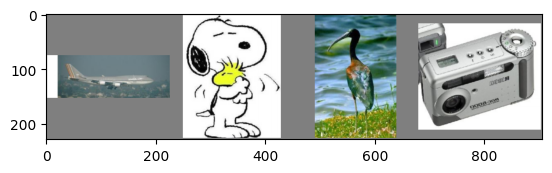

airplanes  snoopy     ibis       camera    


In [18]:


# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:10s}' for j in range(batch_size)))

# Define a Loss function and optimizer

# Train

In [19]:
def train(net, train_loader, criterion, optimizer, device, epochs=2):
    print_every_n_batch = (len(train_loader) / batch_size) // 10
    if print_every_n_batch == 0:
        print_every_n_batch = 1
    net.to(device)
    for epoch in range(epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(train_loader):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # Move inputs and labels to the device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            # print(f"Inputs: {inputs.shape = }", flush=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % print_every_n_batch == 0 and i:
                print(
                    f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_every_n_batch:.3f}"
                )
                running_loss = 0.0

    print("Finished Training")


def evaluate_model(net, test_loader, device):
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in test_loader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    # Compute precision, recall, and f1-score for each class
    from sklearn.metrics import precision_recall_fscore_support

    precision, recall, f1score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average="weighted"
    )

    print(f"Accuracy of the network on the {total} test images: {accuracy:.2f}%")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"Weighted F1-score: {f1score:.4f}")

    return accuracy, precision, recall, f1score

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


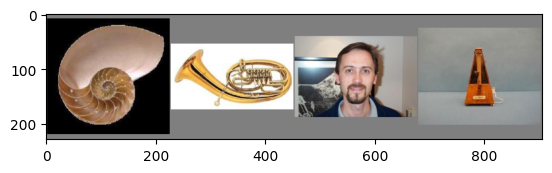

GroundTruth:
 nautilus   euphonium  Faces      metronome 


In [20]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print("GroundTruth:\n", " ".join(f"{classes[labels[j]]:10s}" for j in range(4)))

# Model

In [24]:
# https://pytorch.org/vision/stable/models.html
mobile_net = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
mobile_net.train()
mobile_net.classifier[1] = torch.nn.Linear(mobile_net.classifier[1].in_features, len(classes))
mobile_net

Using cache found in /home/ezalos/.cache/torch/hub/pytorch_vision_v0.10.0
/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [25]:
criterion = nn.CrossEntropyLoss()
params_to_update_1 = []
params_to_update_2 = []
params_to_update_3 = []

for name, param in mobile_net.named_parameters():
    if name.startswith("classifier"):
        param.requires_grad = True
        params_to_update_1.append(param)
    # elif name.startswith("features"):
    #     param.requires_grad = True
    #     params_to_update_2.append(param)
    elif name.startswith("features"):
        param.requires_grad = True
        params_to_update_3.append(param)
    else:
        param.requires_grad = False

print(f"{len(params_to_update_1) = }")
print(f"{len(params_to_update_2) = }")
print(f"{len(params_to_update_3) = }")

optimizer = torch.optim.SGD(
    [
        {"params": params_to_update_1, "lr": 1e-3},
        {"params": params_to_update_2, "lr": 5e-4},
        {"params": params_to_update_3, "lr": 1e-4},
    ],
    momentum=0.9,
)

len(params_to_update_1) = 2
len(params_to_update_2) = 0
len(params_to_update_3) = 156


In [23]:
model_path = "./data/caltech_finetuned_mobile_net.pth"
model = mobile_net
NB_EPOCHS = 3

if True:
    train(model, train_loader, criterion, optimizer, device, epochs=NB_EPOCHS)
    torch.save(model.state_dict(), model_path)
else:
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
evaluate_model(model, test_loader, device)

[1,    44] loss: 4.763
[1,    87] loss: 3.882
[1,   130] loss: 3.769
[1,   173] loss: 3.272
[1,   216] loss: 3.383
[1,   259] loss: 3.088
[1,   302] loss: 3.002
[1,   345] loss: 2.795
[1,   388] loss: 2.667
[1,   431] loss: 2.414
[1,   474] loss: 2.407
[1,   517] loss: 2.314
[1,   560] loss: 2.148
[1,   603] loss: 1.947
[1,   646] loss: 2.149
[1,   689] loss: 2.054
[1,   732] loss: 1.910
[1,   775] loss: 2.115
[1,   818] loss: 2.008
[1,   861] loss: 1.618
[1,   904] loss: 1.878
[1,   947] loss: 1.632
[1,   990] loss: 1.708
[1,  1033] loss: 1.861
[1,  1076] loss: 1.417
[1,  1119] loss: 1.464
[1,  1162] loss: 1.728
[1,  1205] loss: 1.464
[1,  1248] loss: 1.207
[1,  1291] loss: 1.392
[1,  1334] loss: 1.392
[1,  1377] loss: 1.201
[1,  1420] loss: 1.185
[1,  1463] loss: 1.172
[1,  1506] loss: 1.184
[1,  1549] loss: 0.941
[1,  1592] loss: 0.992
[1,  1635] loss: 0.970
[1,  1678] loss: 0.953
[1,  1721] loss: 1.053
[2,    44] loss: 1.146
[2,    87] loss: 0.938
[2,   130] loss: 0.889
[2,   173] 

/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(87.67281105990783, 0.8997782398222114, 0.8767281105990783, 0.8742308361085434)